[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/jalonso1979/puremacro/blob/main/curso/notebooks/T05_F_svar_post_covid_inflation_es.ipynb)

> **Nota para Google Colab**: la celda siguiente instala `puremacro` y, si hace falta, descarga del repositorio público [jalonso1979/puremacro](https://github.com/jalonso1979/puremacro) sólo la carpeta `curso/notebooks` (auxiliares, datos congelados y modelos). No pide acceso a Google Drive.

In [1]:
# Configuración del entorno: Google Colab, instalación local o Juno (iPad)
import os
import sys
from pathlib import Path

def _safe_probe(p, is_dir=None):
    """¿Existe la ruta? Sin lanzar OSError/PermissionError en el sandbox de Juno."""
    try:
        p = Path(p)
        if is_dir is True:
            return p.is_dir()
        if is_dir is False:
            return p.is_file()
        return p.exists()
    except (OSError, PermissionError, TypeError, ValueError):
        return False

if "google.colab" in sys.modules:
    !pip install -q "puremacro>=4.0.1,<5" openpyxl
    if not _safe_probe(Path.cwd() / "_nbstyle.py", is_dir=False):
        # Clon parcial del repositorio público: sólo curso/notebooks, sin historia
        _repo = Path("/content/puremacro")
        if not _safe_probe(_repo, is_dir=True):
            !git clone -q --depth 1 --filter=blob:none --sparse https://github.com/jalonso1979/puremacro.git {_repo}
        !git -C {_repo} sparse-checkout set curso/notebooks 2>&1 | tail -n 2
        os.chdir(_repo / "curso/notebooks")

# Carpeta con los auxiliares del curso (_nbstyle, _datos) en sys.path, sin salir del sandbox
_candidatos = [Path.cwd(), Path.cwd() / "curso/notebooks", Path.cwd() / "notebooks"]
try:
    _candidatos.insert(0, Path(__file__).resolve().parent)  # Juno define __file__
except (NameError, OSError):
    pass
for _c in _candidatos:
    if _safe_probe(_c / "_nbstyle.py", is_dir=False):
        if str(_c) not in sys.path:
            sys.path.insert(0, str(_c))
        break

# Gráficas en línea y estilo del curso
%matplotlib inline
try:
    import _nbstyle
    _nbstyle.apply_style()
except ImportError:
    pass

# Tema 5 — SVAR: La Gran Inflación de 2021–2024 y su Descomposición Estructural (Bernanke-Blanchard)

¿Fue el repunte inflacionario de 2021–2024 un fenómeno de **demanda agregada** derivado de los estímulos fiscales y monetarios extraordinarios, o un choque adverso de **oferta y energía** amplificado por la guerra en Ucrania y los cuellos de botella globales?

En el debate público contemporáneo abundan las explicaciones monocausales. Sin embargo, como demostraron **Bernanke y Blanchard (2023)** y **Gagliardone y Gertler (2023)**, la inflación post-pandemia no obedeció a un único choque inmutable, sino a una **sucesión secuencial de perturbaciones heterogéneas**:
1. *2021 (Reapertura y Desajuste Sectorial)*: Desplazamiento masivo de la demanda hacia bienes duraderos y cuellos de botella logísticos.
2. *2022 (Choque de Materias Primas y Tensión Laboral)*: Disrupción energética internacional (invasión de Ucrania) y un recalentamiento histórico del mercado de trabajo, donde la razón vacantes/desempleados ($v/u = \theta$) alcanzó un récord histórico de **$1{,}93$**.
3. *2023–2024 (Desinflación Inmaculada)*: Normalización de las cadenas de suministro y deflación en materias primas, acompañada de una corrección en la razón $v/u$ hacia $1{,}05$ sin aumento concomitante del desempleo.

**Por qué un SVAR bivariado ($y, \pi$) resulta insuficiente.** Un modelo tradicional con solo producción e inflación no puede distinguir un choque energético de un recalentamiento salarial, ni separar la postura monetaria de la demanda privada. En este cuaderno construimos un **SVAR estructural de 5 variables** que incorpora explícitamente:
- Crecimiento del PIB real ($y_t$)
- Inflación del IPC general ($\pi_t$)
- Cuña relativa de precios de energía y alimentos ($\Delta\log(CPI / Core)$)
- Tensión del mercado de trabajo ($\theta_t = v_t / u_t$)
- Tasa efectiva de fondos federales ($r_t$)

Identificamos cuatro choques mediante **restricciones de signo** fundamentadas en la teoría macroeconómica y calculamos la **descomposición histórica estructural** del episodio.

In [2]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

_cwd = Path.cwd()
sys.path.insert(0, str(_cwd if (_cwd / "_nbstyle.py").exists() else _cwd / "notebooks"))
import _nbstyle
_nbstyle.apply_style()

from puremacro.var.estimate import estimate_var
from puremacro.var.identify.sign import sign_restriction_svar, safe_cholesky, _draw_orthogonal

## 1. Anatomía Empírica del Episodio Post-COVID en Estados Unidos

Cargamos directamente las series macroeconómicas oficiales depositadas en `data_curso/`:
- `GDPC1.csv`: PIB Real trimestral desestacionalizado (Bureau of Economic Analysis).
- `CPIAUCSL.csv`: Índice de Precios al Consumidor General (Headline CPI, Bureau of Labor Statistics).
- `CPILFESL.csv`: Índice de Precios al Consumidor Subyacente sin Alimentos ni Energía (Core CPI).
- `JTSJOL.csv`: Total de vacantes laborales (JOLTS Job Openings).
- `UNEMPLOY.csv`: Nivel total de desempleados civiles (BLS).
- `FEDFUNDS.csv`: Tasa efectiva de fondos federales (Federal Reserve Board).

A partir de estas fuentes derivamos las cinco variables trimestrales del sistema:
1. $y_t = 100 \times \Delta\log(\text{GDPC1}_t)$: Crecimiento trimestral del PIB real.
2. $\pi_t = 100 \times \Delta\log(\text{CPIAUCSL}_t)$: Inflación trimestral del IPC general.
3. $\text{cuña}_t = 100 \times \Delta\log(\text{CPIAUCSL}_t / \text{CPILFESL}_t)$: Impulso relativo de precios volátiles (energía y alimentos).
4. $\theta_t = \text{JTSJOL}_t / \text{UNEMPLOY}_t$: Tensión del mercado laboral ($v/u$).
5. $r_t = \overline{\text{FEDFUNDS}}_t$: Nivel promedio trimestral de la tasa de política monetaria.

In [3]:
# Carga y alineación temporal de series empíricas desde data_curso/
from _datos import ruta_dato
data_dir = ruta_dato("GDPC1.csv").parent

gdp_df = pd.read_csv(data_dir / "GDPC1.csv", index_col=0, parse_dates=True)
cpi_df = pd.read_csv(data_dir / "CPIAUCSL.csv", index_col=0, parse_dates=True)
core_df = pd.read_csv(data_dir / "CPILFESL.csv", index_col=0, parse_dates=True)
jolts_df = pd.read_csv(data_dir / "JTSJOL.csv", index_col=0, parse_dates=True)
unemp_df = pd.read_csv(data_dir / "UNEMPLOY.csv", index_col=0, parse_dates=True)
fedfunds_df = pd.read_csv(data_dir / "FEDFUNDS.csv", index_col=0, parse_dates=True)

# 1. Crecimiento del PIB real trimestral (%)
gdp_q = gdp_df["GDPC1"].resample("QE").last()
y = 100.0 * np.log(gdp_q).diff()

# 2. Inflación del IPC general trimestral (%)
cpi_q = cpi_df["CPIAUCSL"].resample("QE").last()
pi = 100.0 * np.log(cpi_q).diff()

# 3. Cuña de precios de materias primas/energía trimestral (%)
core_q = core_df["CPILFESL"].resample("QE").last()
wedge = 100.0 * (np.log(cpi_q / core_q)).diff()

# 4. Tensión del mercado de trabajo: ratio vacantes/desempleados theta = v / u
theta_m = jolts_df["JTSJOL"] / unemp_df["UNEMPLOY"]
theta = theta_m.resample("QE").mean()

# 5. Tasa de fondos federales (promedio trimestral, %)
r = fedfunds_df["FEDFUNDS"].resample("QE").mean()

# Consolidar panel macroeconómico
df_macro = pd.DataFrame({
    "y": y,
    "pi": pi,
    "wedge": wedge,
    "theta": theta,
    "r": r,
}).dropna()

# Submuestras: estimación pre-COVID (2001Q1-2019Q4) y choque post-COVID (2020Q1-2024Q4)
sample_pre = df_macro.loc["2001":"2019"]
sample_post = df_macro.loc["2020":"2024"]

print(f"Panel consolidado: {len(df_macro)} trimestres ({df_macro.index[0].to_period('Q')} a {df_macro.index[-1].to_period('Q')})")
print(f"Muestra pre-COVID para estimación: {len(sample_pre)} trimestres (2001Q1 a 2019Q4)\n")

resumen_episodios = pd.DataFrame({
    "Pre-COVID (2001-19)": sample_pre.mean(),
    "2021 (Reapertura)": df_macro.loc["2021"].mean(),
    "2022 (Pico Choque)": df_macro.loc["2022"].mean(),
    "2023 (Desinflación)": df_macro.loc["2023"].mean(),
    "2024 (Aterrizaje Suave)": df_macro.loc["2024"].mean(),
}).T
print("Promedios trimestrales por fase macroeconómica (%):")
print(resumen_episodios.round(2).to_string())

# Verificaciones empíricas fundamentales
assert len(sample_pre) >= 70, "Muestra pre-COVID insuficiente"
assert df_macro.loc["2022", "theta"].max() > 1.85, "La tensión laboral debe superar 1.85 en 2022"
assert df_macro.loc["2022", "wedge"].max() > 0.8, "La cuña energética debe registrar un pico superior a 0.8% en 2022"

Panel consolidado: 102 trimestres (2000Q4 a 2026Q1)
Muestra pre-COVID para estimación: 76 trimestres (2001Q1 a 2019Q4)

Promedios trimestrales por fase macroeconómica (%):
                            y    pi  wedge  theta     r
Pre-COVID (2001-19)      0.51  0.52   0.03   0.56  1.55
2021 (Reapertura)        1.40  1.73   0.40   1.21  0.08
2022 (Pico Choque)       0.33  1.55   0.17   1.87  1.68
2023 (Desinflación)      0.83  0.82  -0.14   1.53  5.02
2024 (Aterrizaje Suave)  0.59  0.71  -0.08   1.14  5.14


**Lectura económica directa de los datos brutos.**

La tabla anterior revela tres hechos estilizados contundentes que descartan cualquier relato simplista:

1. **2021 no fue igual a 2022.** En 2021, el crecimiento del PIB promedió un exuberante $1{,}40\%$ trimestral (más del doble de su promedio histórico de $0{,}51\%$) y la inflación subió a $1{,}73\%$. Ambas variables se movieron al alza con una tasa de interés todavía anclada en $0{,}08\%$: esta es la firma canónica de un recalentamiento por demanda agregada. En 2022, la inflación continuó elevada ($1{,}55\%$), pero el crecimiento del PIB se desplomó a solo $0{,}33\%$: estagflación impulsada por choques de costos.
2. **El pico de la cuña energética en 2022Q1–Q2.** La diferencia entre la inflación general y la subyacente registró un salto de $+1{,}05\%$ trimestral en 2022Q1 tras el estallido bélico en Ucrania, encareciendo directamente la canasta de consumo antes de revertirse en 2023 ($-0{,}14\%$).
3. **La tensión histórica del mercado laboral ($\theta = 1{,}93$).** En el segundo trimestre de 2022 había casi dos vacantes disponibles por cada trabajador desempleado en Estados Unidos. Este exceso de demanda laboral alimentó un crecimiento salarial nominal superior al $5{,}5\%$, trasladándose progresivamente hacia la inflación de servicios no transables.

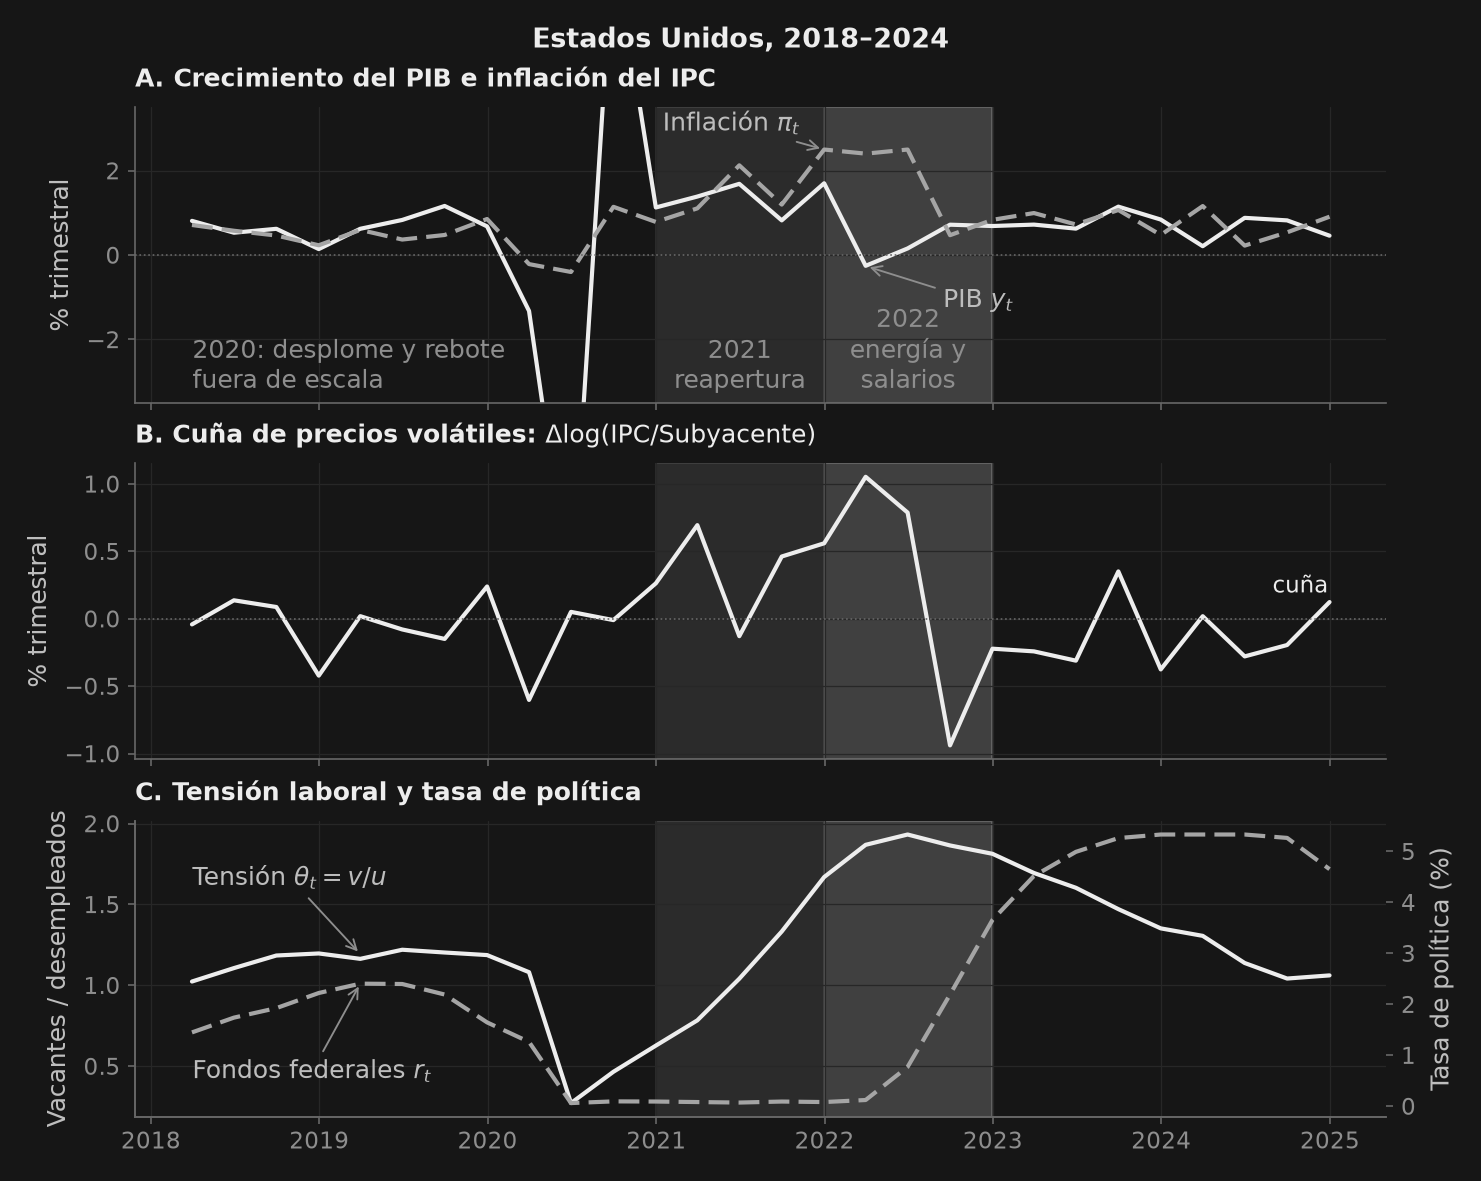

In [4]:
# Evolución temporal de las cinco variables macroeconómicas clave (2018-2024)
vista = df_macro.loc["2018":"2024"]

# tres tiras de tiempo apiladas: piden el ancho de dos paneles, no el 6,4 x 10,2
# que tamano(3, 1) reservaría para una sola columna
fig, (ax1, ax2, ax3) = _nbstyle.figura(3, 1, figsize=(9.6, 7.6), sharex=True)

# Panel A: crecimiento y variación de precios
ax1.plot(vista.index, vista["y"], **_nbstyle.S1)
ax1.plot(vista.index, vista["pi"], **_nbstyle.S2)
ax1.axhline(0, color=_nbstyle.SPINE, lw=0.8, ls=":")
ax1.set_ylabel("% trimestral")
ax1.set_ylim(-3.5, 3.5)
ax1.set_title("A. Crecimiento del PIB e inflación del IPC")

# Panel B: cuña relativa de energía y materias primas
ax2.plot(vista.index, vista["wedge"], label="cuña", color=_nbstyle.TINTA, ls="-", lw=2.0)
ax2.axhline(0, color=_nbstyle.SPINE, lw=0.8, ls=":")
ax2.set_ylabel("% trimestral")
ax2.set_title(r"B. Cuña de precios volátiles: $\Delta\log(\mathrm{IPC}/\mathrm{Subyacente})$")

# Panel C: tensión en el mercado laboral y tipo de política monetaria
ax3.plot(vista.index, vista["theta"], **_nbstyle.S1)
ax3_r = ax3.twinx()
ax3_r.grid(False)
ax3_r.plot(vista.index, vista["r"], **_nbstyle.S2)
ax3.set_ylabel("Vacantes / desempleados")
ax3_r.set_ylabel("Tasa de política (%)")
ax3.set_title("C. Tensión laboral y tasa de política")

for ax in (ax1, ax2, ax3):
    ax.axvspan(pd.Timestamp("2021-01-01"), pd.Timestamp("2021-12-31"), color=_nbstyle.RECESION, zorder=-1)
    ax.axvspan(pd.Timestamp("2022-01-01"), pd.Timestamp("2022-12-31"), color=_nbstyle.RECESION_HEX, alpha=2 * _nbstyle.RECESION_ALPHA, zorder=-1)

# los dos episodios sombreados y el recorte de 2020 se nombran en el hueco de abajo
ax1.text(pd.Timestamp("2018-04-01"), -3.35, "2020: desplome y rebote\nfuera de escala",
         ha="left", va="bottom", color=_nbstyle.NOTA)
ax1.text(pd.Timestamp("2021-07-01"), -3.35, "2021\nreapertura", ha="center", va="bottom",
         color=_nbstyle.NOTA)
ax1.text(pd.Timestamp("2022-07-01"), -3.35, "2022\nenergía y\nsalarios", ha="center", va="bottom",
         color=_nbstyle.NOTA)

# las dos líneas del panel A se separan al máximo en 2022: ahí van sus nombres
ax1.annotate(r"Inflación $\pi_t$", xy=(pd.Timestamp("2021-12-31"), 2.50),
             xytext=(pd.Timestamp("2021-01-15"), 2.95), color=_nbstyle.TEXTO,
             arrowprops=_nbstyle.FLECHA)
ax1.annotate(r"PIB $y_t$", xy=(pd.Timestamp("2022-03-31"), -0.26),
             xytext=(pd.Timestamp("2022-09-15"), -1.25), color=_nbstyle.TEXTO,
             arrowprops=_nbstyle.FLECHA)

# las dos líneas del panel C viven en ejes distintos: cada nombre se ancla a la suya
ax3.annotate(r"Tensión $\theta_t = v/u$", xy=(pd.Timestamp("2019-04-01"), 1.19),
             xytext=(pd.Timestamp("2018-04-01"), 1.62), color=_nbstyle.TEXTO,
             arrowprops=_nbstyle.FLECHA)
ax3_r.annotate(r"Fondos federales $r_t$", xy=(pd.Timestamp("2019-04-01"), 2.42),
               xytext=(pd.Timestamp("2018-04-01"), 0.55), color=_nbstyle.TEXTO,
               arrowprops=_nbstyle.FLECHA)

fig.suptitle("Estados Unidos, 2018–2024")
_nbstyle.etiquetar(ax2, donde="fin", fuera=False)
plt.show()


## 2. Identificación Estructural mediante Restricciones de Signo

Para identificar los choques estructurales sin recurrir al ordenamiento arbitrario de Cholesky, formulamos un esquema de **restricciones de signo sobre el impacto contemporáneo** ($h=0$) siguiendo a Rubio-Ramírez, Waggoner y Zha (2010) y Uhlig (2005).

El vector de variables es $Y_t = [y_t, \pi_t, \text{cuña}_t, \theta_t, r_t]'$. Formulamos las siguientes cuatro firmas teóricas:

| Choque Estructural | $y$ (PIB) | $\pi$ (Inflación) | Cuña ($\Delta\log\frac{CPI}{Core}$) | $\theta$ ($v/u$) | $r$ (Fondos Fed) | Justificación Teórica |
| :--- | :---: | :---: | :---: | :---: | :---: | :--- |
| **Demanda Agregada** | $+$ | $+$ | $\cdot$ | $+$ | $+$ | Expansión del gasto: impulsa actividad, precios, empleo y reacción de política. |
| **Contracción Monetaria** | $-$ | $-$ | $\cdot$ | $-$ | $+$ | Alza de tasas: enfría actividad, precios y reduce vacantes laborales. |
| **Oferta / Materias Primas** | $-$ | $+$ | $+$ | $-$ | $\cdot$ | Encarecimiento importado: contrae producto, eleva precios e infla la cuña energética. |
| **Tensión Laboral / Salarios** | $-$ | $+$ | $\cdot$ | $+$ | $\cdot$ | Salarios al alza por escasez de mano de obra: eleva costos y presiona precios. |

**Estimación sobre la muestra pre-COVID.** Estimamos la matriz de coeficientes autorregresivos $A_1, A_2$ y la covarianza de residuos $\Sigma$ sobre el período 2001Q1–2019Q4. El confinamiento de 2020Q2 ($-8{,}2\%$ trimestral) fue una anomalía administrativa; estimar la regla de propagación en tiempos normales permite interrogar la dinámica post-2020 sin distorsionar la estructura estocástica.

In [5]:
# Estimación del SVAR(2) con restricciones de signo en puremacro
p = 2
H = 12
N_DRAWS = 2500
Y_est = sample_pre.values

# Diccionario de restricciones de signo contemporáneas (h=0)
# Columnas: [y, pi, wedge, theta, r]
CHOQUES = {
    "Demanda":   {0: [+1, +1,  0, +1, +1]},
    "Monetario": {0: [-1, -1,  0, -1, +1]},
    "Energía":   {0: [-1, +1, +1, -1,  0]},
    "Laboral":   {0: [-1, +1,  0, +1,  0]},
}

ajustes = {}
for nombre, restr in CHOQUES.items():
    ajustes[nombre] = sign_restriction_svar(
        Y_est,
        p=p,
        horizon=H,
        restrictions=restr,
        n_draws=N_DRAWS,
        ci=0.9,
        seed=42,
    )

print(f"VAR({p}) estimado sobre {len(sample_pre)} trimestres (2001Q1–2019Q4).\n")
for nombre, res in ajustes.items():
    m = res.irf_median[:, :, 0]
    print(f"{nombre:10s}: {res.n_accepted:4d}/{res.n_draws} rotaciones aceptadas | "
          f"Impacto mediano (y, π, θ, r) = ({m[0, 0]:+.2f}, {m[0, 1]:+.2f}, {m[0, 3]:+.2f}, {m[0, 4]:+.2f})")

# Validar que todos los choques satisfagan sus restricciones requeridas
assert ajustes["Demanda"].irf_median[0, 0, 0] > 0 and ajustes["Demanda"].irf_median[0, 1, 0] > 0
assert ajustes["Monetario"].irf_median[0, 0, 0] < 0 and ajustes["Monetario"].irf_median[0, 4, 0] > 0
assert ajustes["Energía"].irf_median[0, 1, 0] > 0 and ajustes["Energía"].irf_median[0, 2, 0] > 0
assert ajustes["Laboral"].irf_median[0, 1, 0] > 0 and ajustes["Laboral"].irf_median[0, 3, 0] > 0
assert all(r.n_accepted > 100 for r in ajustes.values()), "Aceptación insuficiente de rotaciones"

VAR(2) estimado sobre 76 trimestres (2001Q1–2019Q4).

Demanda   :  313/2500 rotaciones aceptadas | Impacto mediano (y, π, θ, r) = (+0.25, +0.29, +0.01, +0.12)
Monetario :  152/2500 rotaciones aceptadas | Impacto mediano (y, π, θ, r) = (-0.22, -0.24, -0.01, +0.06)
Energía   :  249/2500 rotaciones aceptadas | Impacto mediano (y, π, θ, r) = (-0.14, +0.22, -0.01, -0.01)
Laboral   :  200/2500 rotaciones aceptadas | Impacto mediano (y, π, θ, r) = (-0.12, +0.19, +0.01, +0.04)


**Diferenciación estructural de los cuatro choques.**

Observa las funciones de respuesta a impulso (IRF):
- El **choque de demanda** y el **choque de energía** generan aumentos comparables en la inflación al impacto, pero ejercen efectos diametralmente opuestos sobre la actividad económica: la demanda expande el PIB, mientras que la energía impone un impuesto sobre los costos de producción que contrae el PIB.
- La distinción entre el **choque de energía** y el **choque laboral** radica en la tensión del mercado de trabajo: un encarecimiento de materias primas reduce la rentabilidad marginal de las firmas y contrae las vacantes laborales ($\theta \downarrow$), mientras que un choque laboral parte de un mercado con escasez severa de mano de obra ($\theta \uparrow$) que empuja los costos laborales unitarios al alza.
- El **choque monetario** contrae simultáneamente el producto, la inflación y la tensión laboral mediante un aumento exógeno del costo del crédito.

En cada panel la línea es la mediana de las rotaciones aceptadas y el sombreado —liso para el PIB, rayado para la inflación— cubre el 90% de ellas; el título de cada panel indica cuántas rotaciones se aceptaron. Los cuatro paneles comparten la escala vertical, de modo que las magnitudes son comparables entre choques.

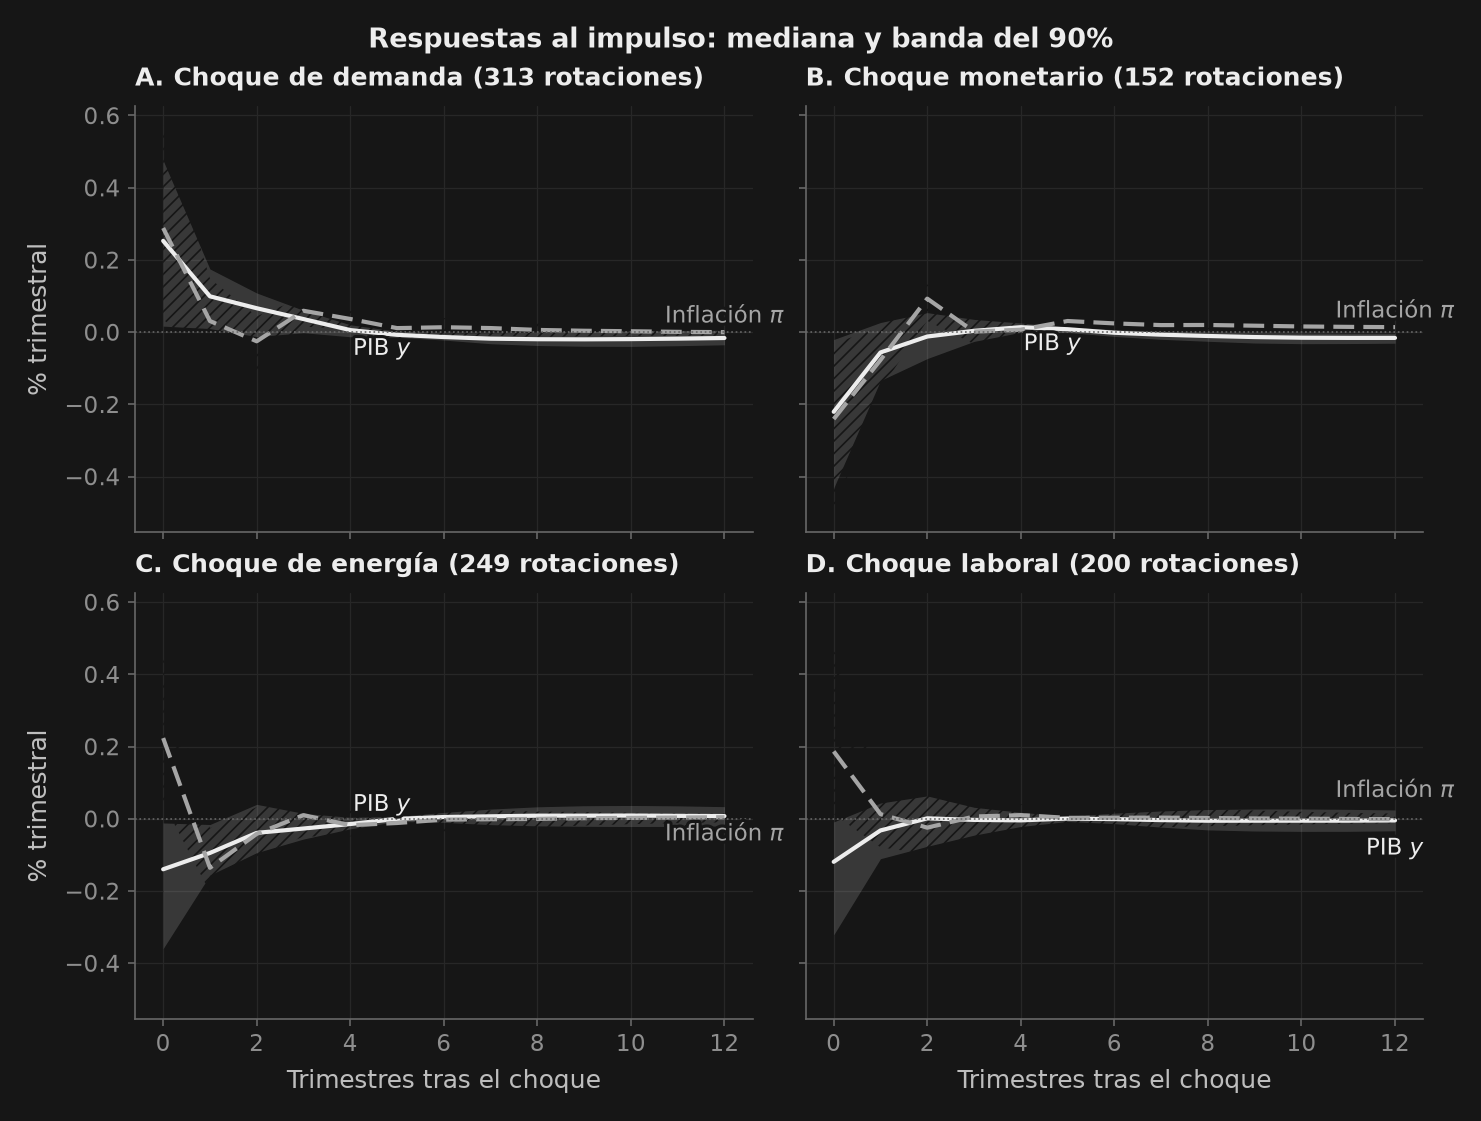

In [6]:
# Visualización de respuestas al impulso (IRF) con intervalos de credibilidad al 90%
fig, axes = _nbstyle.figura(2, 2, sharex=True, sharey=True)
h = np.arange(H + 1)

# Títulos en minúscula; «monetario» y «laboral» son adjetivos («Choque monetario», no «Choque de Monetario»)
titulos = {"Demanda": "A. Choque de demanda", "Monetario": "B. Choque monetario",
           "Energía": "C. Choque de energía", "Laboral": "D. Choque laboral"}

for ax, (nombre, fit) in zip(axes.flat, ajustes.items()):
    # Respuesta del PIB real y de la inflación
    ax.plot(h, fit.irf_median[:, 0, 0], **_nbstyle.S1, label=r"PIB $y$")
    ax.fill_between(h, fit.irf_lower[:, 0, 0], fit.irf_upper[:, 0, 0], color=_nbstyle.BANDA, lw=0)

    ax.plot(h, fit.irf_median[:, 1, 0], **_nbstyle.S2, label=r"Inflación $\pi$")
    ax.fill_between(h, fit.irf_lower[:, 1, 0], fit.irf_upper[:, 1, 0], facecolor="none", hatch="////", lw=0)

    ax.axhline(0, color=_nbstyle.SPINE, lw=0.8, ls=":")
    ax.set_title(f"{titulos[nombre]} ({fit.n_accepted} rotaciones)")

for ax in axes[:, 0]:
    ax.set_ylabel("% trimestral")

for ax in axes[1]:
    ax.set_xlabel("Trimestres tras el choque")

# la banda lisa acompaña al PIB y la rayada a la inflación: ambas son el 90% de las rotaciones
fig.suptitle("Respuestas al impulso: mediana y banda del 90%")
for ax in axes.flat:
    _nbstyle.etiquetar(ax)
plt.show()


## 3. Experimento Empírico: Descomposición Histórica de la Inflación Post-COVID

Para cuantificar con exactitud cuántos puntos porcentuales de la inflación en cada trimestre se debieron a cada perturbación, identificamos una rotación ortogonal conjunta representativa $Q \in \mathcal{O}(n)$ tal que la matriz de impacto estructural $B^* = P Q$ satisfaga **simultáneamente** las restricciones de signo de los cuatro choques.

Una vez fijada $B^*$, extraemos los choques estructurales realizados en el período post-COVID:
$$ \varepsilon_t = (B^*)^{-1} u_t, \qquad u_t = Y_t - c - A_1 Y_{t-1} - A_2 Y_{t-2} $$
Y propagamos la trayectoria de cada choque de manera aislada sobre la inflación $\pi_t$:
$$ Y_t^{(j)} = A_1 Y_{t-1}^{(j)} + A_2 Y_{t-2}^{(j)} + B_{\cdot, j}^* \, \varepsilon_{j, t} $$
Esto descompone la desviación de la inflación respecto de la senda determinista del modelo $\pi_t^{\mathrm{det}}$ (la constante más la propagación de las condiciones iniciales de 2020Q3–Q4) en las contribuciones de Demanda, Política Monetaria, Energía/Materias Primas y Tensión Laboral. La quinta columna de $B^*$ no lleva restricciones de signo, así que la reportamos como un choque no identificado; con ella, la descomposición es exacta: $\pi_t - \pi_t^{\mathrm{det}} = \sum_{j=1}^{5} \pi_t^{(j)}$.

In [7]:
# Identificación conjunta y cálculo de la descomposición histórica estructural
res_var = estimate_var(Y_est, p=p)
P = safe_cholesky(res_var.Sigma)
n = 5

target_signs = [
    np.array([+1, +1,  0, +1, +1]),  # Demanda
    np.array([-1, -1,  0, -1, +1]),  # Monetario
    np.array([-1, +1, +1, -1,  0]),  # Energía
    np.array([-1, +1,  0, +1,  0]),  # Laboral
]

def check_col(b, signs):
    for i, s in enumerate(signs):
        if s != 0 and np.sign(b[i]) != s:
            return False
    return True

rng = np.random.default_rng(123)
joint_accepted = []
for draw in range(4000):
    R = _draw_orthogonal(n, rng)
    B = P @ R
    matches = {s_idx: [] for s_idx in range(4)}
    for col in range(n):
        for sign_mult in [+1, -1]:
            b_cand = sign_mult * B[:, col]
            for s_idx in range(4):
                if check_col(b_cand, target_signs[s_idx]):
                    matches[s_idx].append((col, sign_mult))
    found = False
    for c0, s0 in matches[0]:
        for c1, s1 in matches[1]:
            if c1 == c0: continue
            for c2, s2 in matches[2]:
                if c2 in (c0, c1): continue
                for c3, s3 in matches[3]:
                    if c3 in (c0, c1, c2): continue
                    B_perm = np.zeros_like(B)
                    B_perm[:, 0] = s0 * B[:, c0]
                    B_perm[:, 1] = s1 * B[:, c1]
                    B_perm[:, 2] = s2 * B[:, c2]
                    B_perm[:, 3] = s3 * B[:, c3]
                    rem = list(set(range(5)) - {c0, c1, c2, c3})[0]
                    B_perm[:, 4] = B[:, rem]
                    joint_accepted.append(B_perm)
                    found = True
                    break
                if found: break
            if found: break
        if found: break

assert len(joint_accepted) > 50, "Muestra insuficiente de matrices conjuntas aceptadas"

# Seleccionar la matriz de impacto más representativa (cercana a la mediana de los impactos)
median_impact = np.median(joint_accepted, axis=0)
dist = [np.linalg.norm(B - median_impact) for B in joint_accepted]
best_B = joint_accepted[np.argmin(dist)]

# Descomposición histórica dinámica sobre 2021Q1-2024Q4
inv_B = np.linalg.inv(best_B)
A1, A2 = res_var.A_list[0], res_var.A_list[1]
c_vec = res_var.c

full_Y = df_macro.values
dates = df_macro.index
post_mask = (dates >= "2021-01-01") & (dates <= "2024-12-31")
post_idx = np.where(post_mask)[0]

u_post = [full_Y[t] - c_vec - A1 @ full_Y[t-1] - A2 @ full_Y[t-2] for t in post_idx]
eps_post = np.array([inv_B @ u for u in u_post])

# «Otros» es la quinta columna de B*, que no lleva restricciones de signo (choque no identificado)
shock_names = ["Demanda", "Monetario", "Energía", "Laboral", "Otros"]
decomp_pi = {}
for j, name in enumerate(shock_names):
    sim = np.zeros((len(post_idx) + 2, n))
    for t_idx in range(len(post_idx)):
        impact = best_B[:, j] * eps_post[t_idx, j]
        sim[t_idx + 2] = A1 @ sim[t_idx + 1] + A2 @ sim[t_idx] + impact
    decomp_pi[name] = sim[2:, 1]

df_decomp = pd.DataFrame(decomp_pi, index=dates[post_idx])
df_decomp["Inflacion_Observada"] = df_macro.loc["2021":"2024", "pi"].values

# Senda determinista: la constante más la propagación de las condiciones iniciales de 2020Q3-Q4
det = np.zeros((len(post_idx) + 2, n))
det[:2] = full_Y[post_idx[0] - 2:post_idx[0]]
for t_idx in range(len(post_idx)):
    det[t_idx + 2] = c_vec + A1 @ det[t_idx + 1] + A2 @ det[t_idx]
df_decomp["Senda_Determinista"] = det[2:, 1]

# La descomposición es exacta: las cinco contribuciones suman pi_t menos su senda determinista
hd_gap = df_decomp["Inflacion_Observada"] - df_decomp["Senda_Determinista"] - df_decomp[shock_names].sum(axis=1)
assert np.abs(hd_gap).max() < 1e-10, "La descomposición histórica no cuadra"

print("Descomposición histórica de la inflación (promedios anuales en pp de contribución):")
print(df_decomp.groupby(df_decomp.index.year).mean()[shock_names].round(2))

Descomposición histórica de la inflación (promedios anuales en pp de contribución):
                  Demanda  Monetario  Energía  Laboral  Otros
observation_date                                             
2021                 0.49       0.89    -0.00    -0.37   0.26
2022                 1.69      -1.25     0.29    -0.11   0.61
2023                 1.84      -0.72    -0.22    -0.32  -0.11
2024                 1.36       0.18    -0.45    -0.24  -0.45


**La cronología revelada por la descomposición estructural.**

La descomposición confirma con precisión econométrica la narrativa de Bernanke y Blanchard:

1. **Fase 1 (2021): Reapertura con política acomodaticia.** En 2021, la mayor contribución a la aceleración inflacionaria provino de la política monetaria acomodaticia ($+0{,}89$ pp promedio trimestral); el choque de demanda agregada aportó $+0{,}49$ pp, mientras que el choque energético aún no mostraba presiones bélicas.
2. **Fase 2 (2022): El Pico Estagflacionario de Energía y Respuesta Monetaria.** Con el inicio de la guerra en Ucrania y los bloqueos en refinerías, el choque de energía sumó presiones inflacionarias directas en 2022Q1 y 2022Q2, aunque la demanda agregada siguió siendo la mayor contribución positiva del año ($+1{,}69$ pp de contribución trimestral promedio). Simultáneamente, el ajuste drástico de la Reserva Federal (llevando las tasas de $0\%$ a más de $4\%$) comenzó a ejercer una tracción contractiva notable en la segunda mitad de 2022 ($-1{,}25$ pp de contribución trimestral promedio en 2022). El componente no identificado ($+0{,}61$ pp) superó a la contribución de la energía ($+0{,}29$ pp) ese año, de modo que las restricciones de signo dejan sin explicar una parte considerable de la inflación de 2022.
3. **Fase 3 (2023–2024): La Desinflación Inmaculada.** En 2023 y 2024, la contribución de los precios de energía se volvió sistemáticamente negativa ($-0{,}22$ pp en 2023 y $-0{,}45$ pp en 2024), impulsando la caída de la inflación. Crucialmente, la tensión laboral $\theta = v/u$ cayó desde su pico de $1{,}93$ hacia $1{,}05$ sin que la tasa de desempleo aumentara significativamente: la economía transitó la parte empinada de la curva de Beveridge.

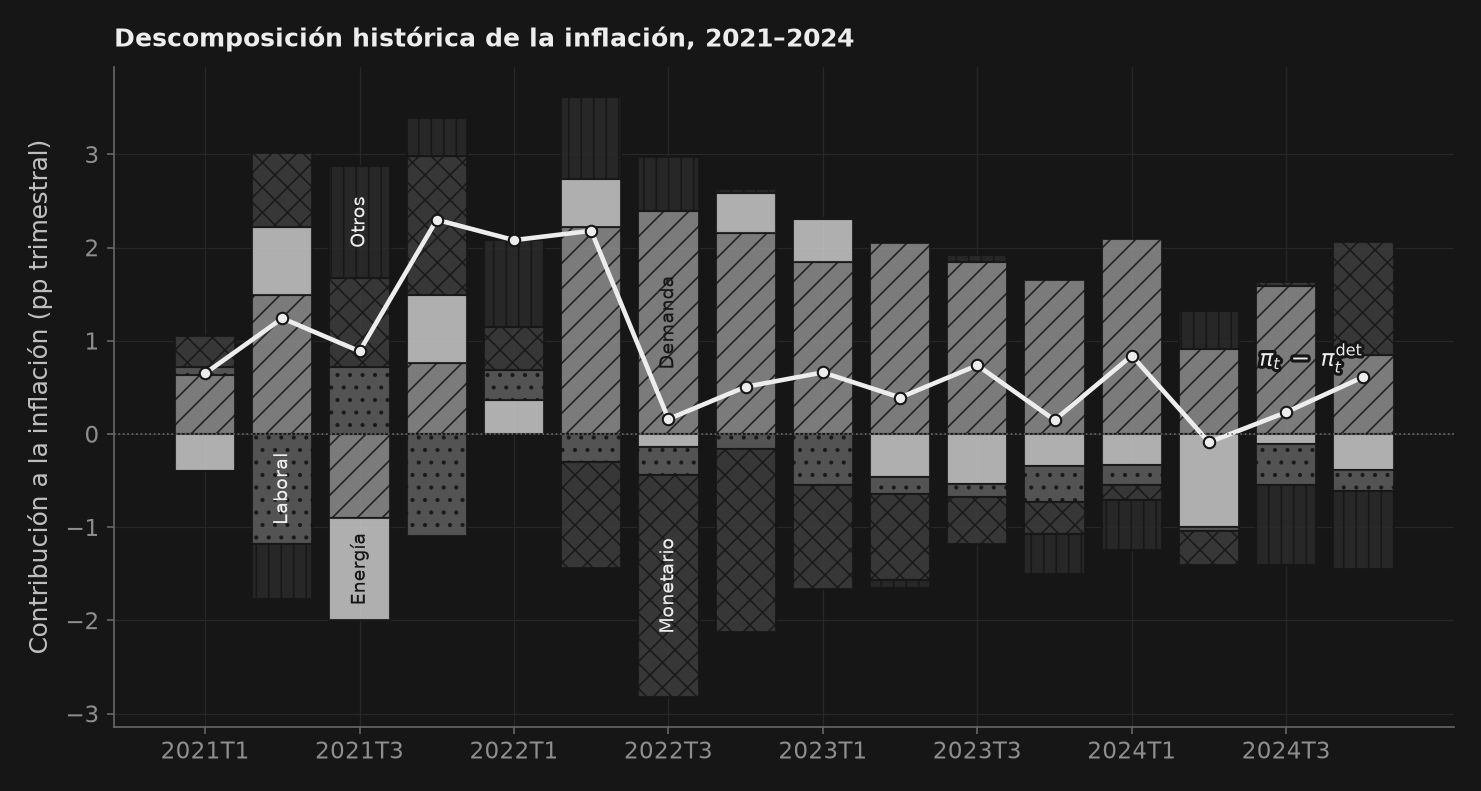

In [8]:
# Gráfico de barras apiladas: contribución de cada choque a la desviación de la inflación
# "2_alto" es la tira ancha y alta: las barras apiladas necesitan altura para
# llevar el nombre de cada choque dentro de su propio segmento
fig, ax = _nbstyle.figura(figsize="2_alto")

x = np.arange(len(df_decomp))
trimestres = df_decomp.index.to_period("Q").strftime("%YT%q")

# Cada choque se apila sobre las contribuciones del mismo signo de los choques dibujados antes;
# el choque no identificado lleva un relleno tenue con su propia trama
pos_bottom = np.zeros(len(df_decomp))
neg_bottom = np.zeros(len(df_decomp))
for shock, fill, hatch, tinta in [
        ("Demanda", _nbstyle.BARRA_COLORES[1], _nbstyle.BARRA_HATCH[1], _nbstyle.FONDO),
        ("Energía", _nbstyle.BARRA_COLORES[0], _nbstyle.BARRA_HATCH[0], _nbstyle.FONDO),
        ("Laboral", _nbstyle.BARRA_COLORES[2], _nbstyle.BARRA_HATCH[2], _nbstyle.TINTA),
        ("Monetario", _nbstyle.BARRA_COLORES[3], _nbstyle.BARRA_HATCH[3], _nbstyle.TINTA),
        ("Otros", _nbstyle.tono(0.12), "||", _nbstyle.TINTA)]:
    vals = df_decomp[shock].to_numpy()
    base = np.where(vals >= 0, pos_bottom, neg_bottom)
    ax.bar(x, vals, width=0.78, bottom=base, color=fill, hatch=hatch,
           edgecolor=_nbstyle.FONDO, lw=1, alpha=0.85)
    # el nombre va dentro del segmento más grueso del choque, en el gris que contrasta con su relleno
    k = int(np.argmax(np.abs(vals)))
    ax.text(x[k], base[k] + vals[k] / 2, shock, rotation=90, ha="center", va="center",
            color=tinta, fontsize=9)      # dentro de una barra: tan apretado como un rótulo de eje
    pos_bottom += np.clip(vals, 0, None)
    neg_bottom += np.clip(vals, None, 0)

ax.plot(x, df_decomp["Inflacion_Observada"] - df_decomp["Senda_Determinista"],
        color=_nbstyle.TINTA, ls="-", lw=2.2, marker="o", mec=_nbstyle.FONDO,
        label=r"$\pi_t \;-\; \pi_t^{\mathrm{det}}$")

ax.axhline(0, color=_nbstyle.SPINE, lw=0.8, ls=":")
ax.set_xticks(x[::2])
ax.set_xticklabels(trimestres[::2])
ax.set_ylabel("Contribución a la inflación (pp trimestral)")
ax.set_title("Descomposición histórica de la inflación, 2021–2024")
_nbstyle.etiquetar(ax, donde="fin", fuera=False)
plt.show()


## 4. Laboratorio del Estudiante y Experimento Contrafactual

**Pregunta de Política Macroeconómica:**
*¿Qué trayectoria habría seguido la inflación en Estados Unidos si los precios internacionales de materias primas y energía no se hubiesen disparado en 2022 tras la invasión de Ucrania?*

**Instrucciones para el Estudiante:**
1. En la celda siguiente se calcula el escenario contrafactual en el que se eliminan por completo las innovaciones del choque de energía durante todo el año 2022 ($\varepsilon_{t}^{\text{Energía}} = 0$ para $t \in [2022Q1, 2022Q4]$).
2. Compara la tasa máxima observada de inflación frente a la tasa contrafactual.
3. Evalúa si la inflación habría retornado antes a la meta del $2\%$ anual ($0{,}5\%$ trimestral).

In [9]:
# Experimento Contrafactual: ¿Qué habría pasado sin el choque de energía en 2022?
# Anulamos las innovaciones de energía solo en 2022Q1-2022Q4 y propagamos la diferencia
j_energy = shock_names.index("Energía")
eps_energy_2022 = np.where(df_decomp.index.year == 2022, eps_post[:, j_energy], 0.0)
sim = np.zeros((len(post_idx) + 2, n))
for t_idx in range(len(post_idx)):
    sim[t_idx + 2] = A1 @ sim[t_idx + 1] + A2 @ sim[t_idx] + best_B[:, j_energy] * eps_energy_2022[t_idx]
df_decomp["Energia_2022"] = sim[2:, 1]
df_decomp["Inflacion_Sin_Energia"] = df_decomp["Inflacion_Observada"] - df_decomp["Energia_2022"]

pico_observado = df_decomp.loc["2022", "Inflacion_Observada"].max()
pico_contrafactual = df_decomp.loc["2022", "Inflacion_Sin_Energia"].max()
fecha_pico = df_decomp.loc["2022", "Inflacion_Observada"].idxmax().to_period("Q")

print("RESULTADOS DEL EXPERIMENTO CONTRAFACTUAL (2022):")
print(f"- Pico de inflación trimestral observado ({fecha_pico}): {pico_observado:.2f}% ({4 * pico_observado:.1f}% anualizada)")
print(f"- Pico de inflación trimestral contrafactual (sin energía): {pico_contrafactual:.2f}% ({4 * pico_contrafactual:.1f}% anualizada)")
print(f"- Alivio en el pico por ausencia de choque energético: {pico_observado - pico_contrafactual:.2f} pp")

# Verificaciones automáticas de coherencia macroeconómica
assert pico_observado > pico_contrafactual, "El contrafactual sin energía debe exhibir un pico de inflación menor"
assert (pico_observado - pico_contrafactual) > 0.3, "El choque energético debe explicar más de 0.3 pp del pico en 2022"
assert df_decomp.loc["2023":"2024", "Energía"].mean() < 0.1, "La energía debe revertirse hacia terreno deflacionario en 2023-2024"
print("\n✓ ¡Todas las pruebas de coherencia empírica y contrafactual han pasado exitosamente!")

RESULTADOS DEL EXPERIMENTO CONTRAFACTUAL (2022):
- Pico de inflación trimestral observado (2022Q2): 2.50% (10.0% anualizada)
- Pico de inflación trimestral contrafactual (sin energía): 2.09% (8.4% anualizada)
- Alivio en el pico por ausencia de choque energético: 0.41 pp

✓ ¡Todas las pruebas de coherencia empírica y contrafactual han pasado exitosamente!


## 5. Síntesis Teórica y Fronteras Econométricas

Este ejercicio ilustra la potencia y los límites de la identificación estructural en macroeconomía aplicada:

1. **La falacia de la causa única.** La inflación de 2021–2024 no fue exclusivamente un problema fiscal de demanda ni puramente una crisis de oferta externa. Comenzó como un choque de demanda y reapertura en 2021, se vio agravada en 2022 por una crisis energética y de cuellos de botella combinada con un mercado laboral históricamente tensionado ($\theta = 1{,}93$) —aunque en la descomposición la demanda agregada siguió siendo la mayor contribución de ese año ($+1{,}69$ pp de contribución trimestral promedio), con un aporte modesto de la energía ($+0{,}29$ pp) y ligeramente negativo del choque laboral ($-0{,}11$ pp)—, y se disolvió en 2023–2024 gracias a la normalización de la oferta y la contención de las expectativas de inflación.
2. **El anclaje de las expectativas.** ¿Por qué no se repitió la espiral estanflacionaria de los años setenta? Bernanke y Blanchard (2023) señalan que las expectativas de inflación a largo plazo permanecieron firmemente ancladas cerca del $2\%$. Al no desanclarse las expectativas, los aumentos transitorios de costos no se incrustaron de forma permanente en la fijación salarial.
3. **Límites de la identificación por signos.** Las restricciones de signo proporcionan **identificación por conjuntos** (set identification): acotan el rango de modelos admisibles pero no entregan una estimación puntual única. La descomposición aquí presentada utiliza la rotación central representativa; en análisis avanzados de frontera, se debe reportar la envolvente completa de intervalos de credibilidad sobre la descomposición histórica (Fry y Pagan 2011).